In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

4143134


In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [3]:
def build_graph(sequence, score_map, distance_map=None, sep_min=0):
    
    N = len(sequence)

    # score map to tensor
    score_map = torch.tensor(score_map, dtype=torch.float)
    score_map = torch.log(score_map + 1.0)  #renormalization to see again when we have more data
   
    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        distance_map = torch.tensor(distance_map, dtype=torch.float)
        distance_map=torch.log((distance_map)/8) #renormalization to see again when we have more data
        known = torch.isfinite(distance_map)
        labels = distance_map
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok

    # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)

    edge_attr = score_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1)

    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=mask
    )

In [4]:
folder_path = "Data"

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']
        data = build_graph(sequence, contact_map_DCA, distance_map)
        all_data.append(data)


from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)



In [5]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [6]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [7]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)

In [ ]:
def triangle_inequality_loss_sampled(pred_dist_matrix, num_samples=10000):
    B, N, _ = pred_dist_matrix.shape
    # Randomly pick i, j, k indices
    i = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    j = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    k = torch.randint(0, N, (num_samples,), device=pred_dist_matrix.device)
    
    d_ij = torch.exp(pred_dist_matrix[:, i, j])
    d_ik = torch.exp(pred_dist_matrix[:, i, k])
    d_kj = torch.exp(pred_dist_matrix[:, k, j])
    
    violations = torch.relu(d_ij - (d_ik + d_kj))
    return torch.mean(violations**2)

In [20]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=32, mlp_hidden_ch=16, GNN_layers=4).to(device)

save_path = "best_model_regressor.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)


loss_fn = torch.nn.HuberLoss() 
##controllare parametri, valore medio sul grafo o da un valore diverso ad ogni edge? In tal modo quelle grosse sonon molto più pesanti e rilevanti (dividere per numero do edge???)
#vedere sec'e un  modo per meedialre la loss sugli edge (moduli di torch geometric o torch scatter)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=5,min_lr=1e-6)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0

for epoch in range(100): 

    model.train()
    total_loss = 0.0
    total_edges = 0

    for batch in train_loader:
        batch = batch.to(device) 

        optimizer.zero_grad() 
        _, pred_dist = model(batch)

        mask = batch.edge_mask
        true_dist = batch.y.squeeze(-1)
        pred_dist = pred_dist.squeeze(-1)

        main_loss = loss_fn(pred_dist[mask], true_dist[mask])
        from torch_geometric.utils import to_dense_adj
        dense_dist = to_dense_adj(batch.edge_index[:,mask], batch.batch, edge_attr=pred_dist[mask])

        tri_loss = triangle_inequality_loss_sampled(dense_dist)
        
        loss = main_loss + 0.1 * tri_loss

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()
    
    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break



Epoch 0: Train Loss=0.3700, Val Loss=0.1966
Epoch 1: Train Loss=0.1913, Val Loss=0.1702
Epoch 2: Train Loss=0.1729, Val Loss=0.1621
Epoch 3: Train Loss=0.1655, Val Loss=0.1541
Epoch 4: Train Loss=0.1596, Val Loss=0.1506
Epoch 5: Train Loss=0.1559, Val Loss=0.1455
Epoch 6: Train Loss=0.1527, Val Loss=0.1424
Epoch 7: Train Loss=0.1494, Val Loss=0.1396
Epoch 8: Train Loss=0.1464, Val Loss=0.1366
Epoch 9: Train Loss=0.1435, Val Loss=0.1337
Epoch 10: Train Loss=0.1403, Val Loss=0.1314
Epoch 11: Train Loss=0.1374, Val Loss=0.1275
Epoch 12: Train Loss=0.1338, Val Loss=0.1249
Epoch 13: Train Loss=0.1313, Val Loss=0.1224
Epoch 14: Train Loss=0.1290, Val Loss=0.1206
Epoch 15: Train Loss=0.1272, Val Loss=0.1190
Epoch 16: Train Loss=0.1252, Val Loss=0.1174
Epoch 17: Train Loss=0.1239, Val Loss=0.1164
Epoch 18: Train Loss=0.1228, Val Loss=0.1172
Epoch 19: Train Loss=0.1226, Val Loss=0.1142
Epoch 20: Train Loss=0.1213, Val Loss=0.1135
Epoch 21: Train Loss=0.1204, Val Loss=0.1135
Epoch 22: Train Loss

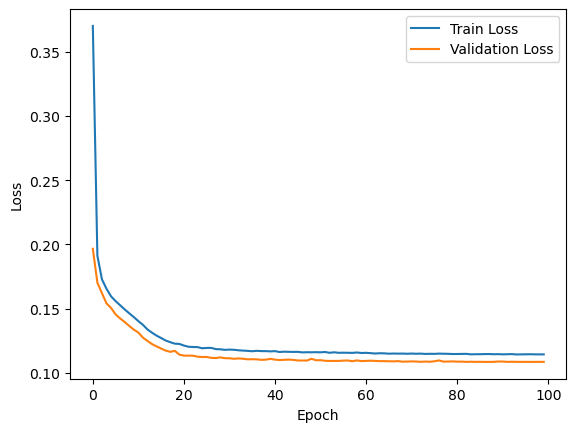

In [21]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [22]:
save_path = "best_model_regressor.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [23]:
def graph_to_matrix(data, values, mask=None):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index

    if mask is not None:
        edge_index = edge_index[:, mask]
        values = values[mask]
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

In [24]:
def loss_per_graph(batch, pred_dist, loss_fn):
    scores = pred_dist.squeeze(-1)
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask #& batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    loss_tot = []


    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        loss = loss_fn(g_scores, g_true)
        loss_tot.append(loss.detach().cpu().item())
    
    return loss_tot

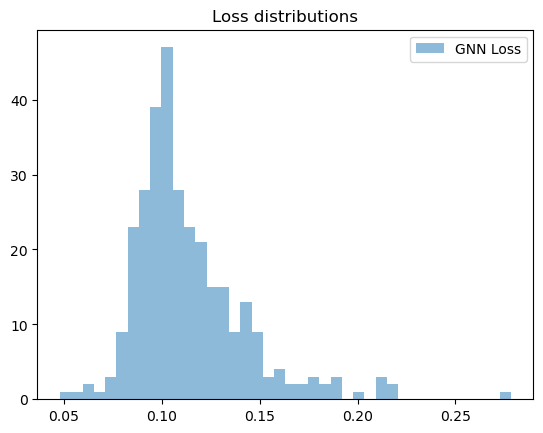

[0.12211982160806656, 0.14848795533180237, 0.14963774383068085, 0.09508028626441956, 0.09209731221199036, 0.09940909594297409, 0.09639157354831696, 0.08005419373512268, 0.0823136642575264, 0.09991823136806488, 0.08527160435914993, 0.10059231519699097, 0.0886523500084877, 0.09697991609573364, 0.09814802557229996, 0.16097837686538696, 0.10232675075531006, 0.15254950523376465, 0.12875418365001678, 0.09532628208398819, 0.1284155249595642, 0.11428261548280716, 0.10442658513784409, 0.12132619321346283, 0.10119658708572388, 0.1305866241455078, 0.08933740854263306, 0.10651561617851257, 0.08532050251960754, 0.10165458172559738, 0.1698015332221985, 0.10430034250020981, 0.09392447024583817, 0.08822392672300339, 0.1070960983633995, 0.1029682606458664, 0.10768398642539978, 0.06838557869195938, 0.0892903208732605, 0.09202466160058975, 0.10595282912254333, 0.11954524368047714, 0.0611758828163147, 0.0980885922908783, 0.11187075823545456, 0.14330698549747467, 0.14986273646354675, 0.10571397095918655, 0

In [25]:
all_losses = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_dist = model(batch)

        loss_tot= loss_per_graph(batch,pred_dist,loss_fn)
        all_losses.extend(loss_tot)

plt.hist(all_losses, bins=40, alpha=0.5, label=f"GNN Loss")


plt.legend()
plt.title("Loss distributions")
plt.show()

print(all_losses)
print(max(all_losses))
print(all_losses.index(max(all_losses)))

Data(x=[126, 16], edge_index=[2, 15750], edge_attr=[15750, 1], y=[15750, 1], edge_mask=[15750])


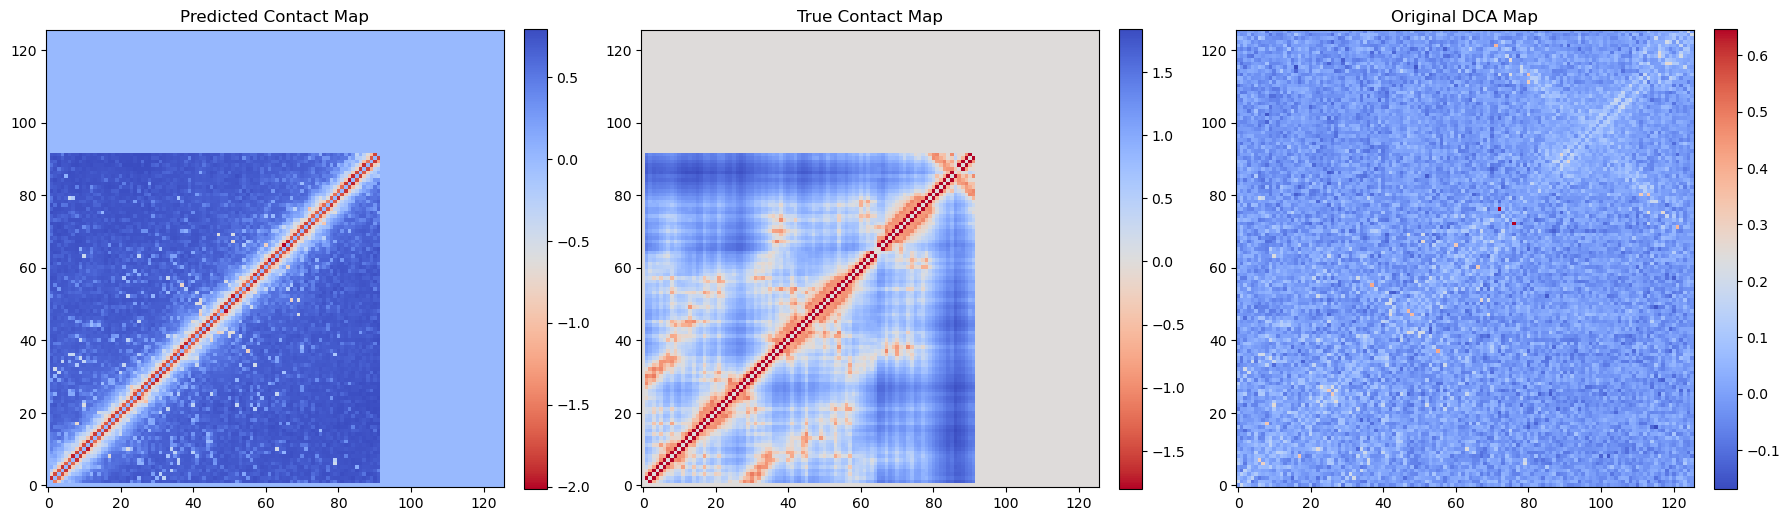

In [27]:
pos=0


i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_dist = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask

pred_dist_map = graph_to_matrix(batch, pred_dist.squeeze(-1).cpu(), mask.cpu())
true_dist_map = graph_to_matrix(batch, batch.y.cpu(),mask.cpu())
original_dca_map = graph_to_matrix(batch, batch.edge_attr.cpu())


fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_dist_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---


im1 = axes[1].imshow(true_dist_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original DCA Map ---
im2 = axes[2].imshow(original_dca_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Original DCA Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()